## 🔧 Cell 1 — Install all libraries

In [ ]:
# Run this first — restart runtime after if prompted
!pip install -q gradio plotly fpdf2 scikit-image scikit-learn tqdm seaborn
!pip install -q opencv-python-headless Pillow
print("✅ All libraries installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 11.6 MB/s eta 0:00:00
✅ All libraries installed


## 📦 Cell 2 — Imports

In [ ]:
import os, gc, random, warnings, shutil, datetime, io, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import psutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

print('='*60)
print('🔥 WILDFIRE INTELLIGENCE SYSTEM v3.0'.center(60))
print('='*60)
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: tf.config.experimental.set_memory_growth(gpus[0], True)
    except: pass
    print(f'GPU        : {gpus[0].name} ✅')
else:
    print('⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU')
print(f'RAM        : {round(psutil.virtual_memory().total/1024**3)} GB')
print('='*60)

            🔥 WILDFIRE INTELLIGENCE SYSTEM v3.0             
TensorFlow : 2.19.0
Keras      : 3.13.2
GPU        : /physical_device:GPU:0 ✅
RAM        : 13 GB


## 📂 Cell 3 — Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

zip_path     = '/content/drive/MyDrive/Wildfire_dataset.zip'
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

if os.path.exists(zip_path):
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print('✅ Extraction complete!')
else:
    print(f'⚠️  Not found: {zip_path}')
    print('Update zip_path to point to your dataset.')

print('\n📁 Dataset structure:')
total = 0
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 3:
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        total += len(imgs)
        if imgs or level == 0:
            print(f'{"  "*level}📂 {os.path.basename(root) or "dataset"}/  ({len(imgs)} images)')
print(f'\n✅ Total: {total:,} images')

Mounted at /content/drive
Extracting dataset...
✅ Extraction complete!

📁 Dataset structure:
📂 dataset/  (0 images)
    📂 nowildfire/  (2820 images)
    📂 wildfire/  (3480 images)
    📂 nowildfire/  (2820 images)
    📂 wildfire/  (3480 images)
    📂 nowildfire/  (14500 images)
    📂 wildfire/  (15750 images)

✅ Total: 42,850 images


## ⚙️ Cell 4 — Config & Class Discovery

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
data_dir   = '/content/dataset'

def find_class_root(base):
    """Walk until we find a folder whose subdirs contain images."""
    for root, dirs, files in os.walk(base):
        for d in sorted(dirs)[:5]:
            p = os.path.join(root, d)
            imgs = [f for f in os.listdir(p)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(imgs) > 5:
                return root
    return base

image_root  = find_class_root(data_dir)
CLASS_NAMES = sorted([d for d in os.listdir(image_root)
                      if os.path.isdir(os.path.join(image_root, d))])
NUM_CLASSES = len(CLASS_NAMES)
print(f'📂 Image root : {image_root}')
print(f'📋 Classes    : {CLASS_NAMES}')

# Build risk map
RISK_MAP = {}
for c in CLASS_NAMES:
    cl = c.lower().replace('_','').replace('-','').replace(' ','')
    if any(x in cl for x in ['nofire','nowildfire','nonfire','safe','clear','normal']):
        RISK_MAP[c] = 'Low Risk'
    elif any(x in cl for x in ['fire','burn','flame','blaze','wildfire','hot']):
        RISK_MAP[c] = 'High Risk'
    else:
        RISK_MAP[c] = 'Low Risk'

print('\n🗺️  Risk mapping:')
for c, r in RISK_MAP.items():
    icon = '🔴' if r == 'High Risk' else '🟢'
    print(f'   {icon} {c:25s} → {r}')

📂 Image root : /content/dataset/valid
📋 Classes    : ['nowildfire', 'wildfire']

🗺️  Risk mapping:
   🟢 nowildfire                → Low Risk
   🔴 wildfire                  → High Risk


## 📊 Cell 5 — Build File Lists & Split

In [ ]:
all_paths, all_labels = [], []
print('\n📊 Image counts:')
for idx, cls in enumerate(CLASS_NAMES):
    d    = os.path.join(image_root, cls)
    imgs = [os.path.join(d, f) for f in os.listdir(d)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f'   {cls:25s}: {len(imgs):,}')
    all_paths  += imgs
    all_labels += [idx] * len(imgs)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

p_train,p_temp,l_train,l_temp = train_test_split(
    all_paths, all_labels, test_size=0.3, random_state=42, stratify=all_labels)
p_val,p_test,l_val,l_test = train_test_split(
    p_temp, l_temp, test_size=0.5, random_state=42)

print(f'\n✅ Train: {len(p_train):,}  Val: {len(p_val):,}  Test: {len(p_test):,}')


📊 Image counts:
   nowildfire               : 2,820
   wildfire                 : 3,480

✅ Train: 4,410  Val: 945  Test: 945


## 🖼️ Cell 6 — Sample Visualization

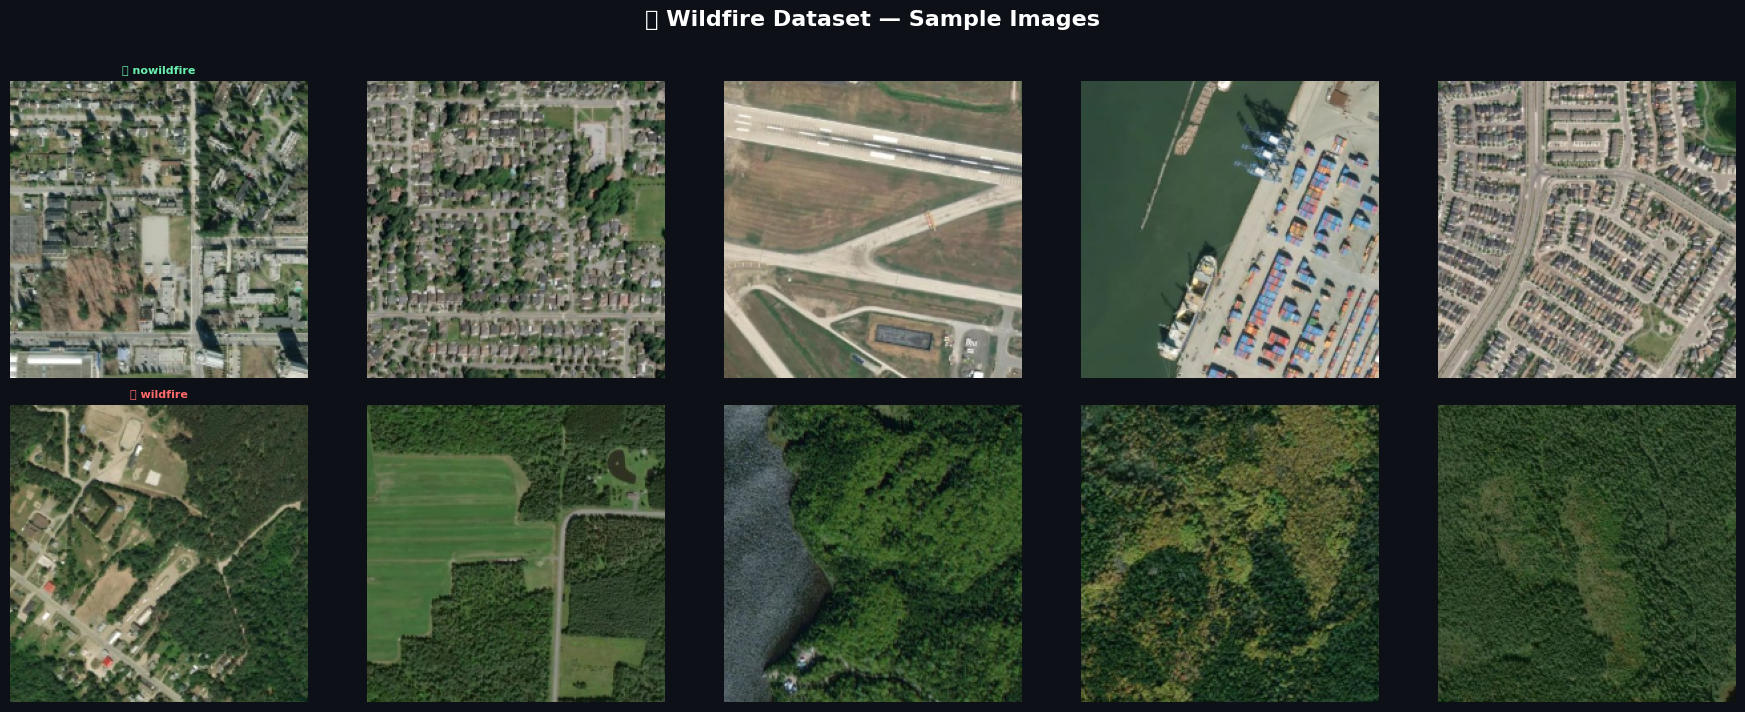

✅ Sample grid saved


In [ ]:
PALETTE = {
    'High Risk': {'border':'#E53935','label_bg':'#B71C1C','title':'#FF6B6B'},
    'Low Risk' : {'border':'#43A047','label_bg':'#1B5E20','title':'#69F0AE'},
}

def load_img_display(path):
    img = cv2.imread(path)
    if img is None: return np.zeros((*IMG_SIZE,3), dtype=np.uint8)
    return cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), IMG_SIZE)

class_paths = {c: [os.path.join(image_root,c,f)
                   for f in os.listdir(os.path.join(image_root,c))
                   if f.lower().endswith(('.jpg','.jpeg','.png'))]
               for c in CLASS_NAMES}

N_COLS, N_ROWS = 5, len(CLASS_NAMES)
fig = plt.figure(figsize=(18, N_ROWS*3+1), facecolor='#0D1117')
fig.suptitle('🔥 Wildfire Dataset — Sample Images', fontsize=16,
             fontweight='bold', color='white', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    risk   = RISK_MAP.get(cls,'Low Risk')
    colors = PALETTE[risk]
    samples = random.sample(class_paths[cls], min(N_COLS, len(class_paths[cls])))
    for col in range(N_COLS):
        ax = fig.add_subplot(N_ROWS, N_COLS, row*N_COLS+col+1)
        if col < len(samples):
            ax.imshow(load_img_display(samples[col]))
        ax.axis('off')
        if col == 0:
            icon = '🔴' if risk=='High Risk' else '🟢'
            ax.set_title(f'{icon} {cls}', color=colors['title'],
                         fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/samples.png', dpi=130, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('✅ Sample grid saved')

## 🚀 Cell 7 — PyDataset (Keras-3 Compatible Pipeline)

In [ ]:
# ════════════════════════════════════════════════════════════
# ROOT CAUSE FIX: Keras 3 cannot use tf.data with string paths.
# Solution: keras.utils.PyDataset loads images in pure numpy/OpenCV.
# The model NEVER sees a string tensor — problem eliminated.
# ════════════════════════════════════════════════════════════

class WildfireDataset(keras.utils.PyDataset):
    def __init__(self, paths, labels, batch_size=32,
                 augment=False, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.paths      = np.array(paths)
        self.labels     = np.array(labels, dtype=np.int32)
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    @staticmethod
    def _load(path):
        img = cv2.imread(path)
        if img is None:
            return np.zeros((*IMG_SIZE, 3), dtype=np.float32)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        img = img.astype(np.float32)
        img = (img / 127.5) - 1.0        # EfficientNet range [-1, 1]
        return img

    @staticmethod
    def _augment(img):
        # horizontal flip
        if random.random() > 0.5:
            img = img[:, ::-1, :]
        # vertical flip
        if random.random() > 0.5:
            img = img[::-1, :, :]
        # brightness jitter
        delta = random.uniform(-0.15, 0.15)
        img   = np.clip(img + delta, -1.0, 1.0)
        # contrast jitter
        factor = random.uniform(0.85, 1.15)
        img    = np.clip(img * factor, -1.0, 1.0)
        return img

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, lbls = [], []
        for i in batch_idx:
            img = self._load(self.paths[i])
            if self.augment:
                img = self._augment(img)
            imgs.append(img)
            lbls.append(self.labels[i])
        return np.array(imgs, dtype=np.float32), np.array(lbls, dtype=np.int32)

train_gen = WildfireDataset(p_train, l_train, BATCH_SIZE, augment=True,  shuffle=True)
val_gen   = WildfireDataset(p_val,   l_val,   BATCH_SIZE, augment=False, shuffle=False)
test_gen  = WildfireDataset(p_test,  l_test,  BATCH_SIZE, augment=False, shuffle=False)

# ── verify ──
imgs_b, lbls_b = train_gen[0]
print(f'✅ imgs: {imgs_b.shape}  dtype={imgs_b.dtype}  '
      f'min={imgs_b.min():.2f}  max={imgs_b.max():.2f}')
print(f'✅ lbls: {lbls_b.shape}  dtype={lbls_b.dtype}')
assert imgs_b.dtype == np.float32
assert lbls_b.dtype == np.int32
assert -1.1 <= imgs_b.min() and imgs_b.max() <= 1.1
print('✅ PyDataset verified — ready to train!')

cw = compute_class_weight('balanced', classes=np.unique(l_train), y=l_train)
class_weight_dict = {int(k): float(v) for k, v in enumerate(cw)}
print(f'\nClass weights: '
      f'{dict((CLASS_NAMES[k],round(v,3)) for k,v in class_weight_dict.items())}')

✅ imgs: (32, 224, 224, 3)  dtype=float32  min=-1.00  max=1.00
✅ lbls: (32,)  dtype=int32
✅ PyDataset verified — ready to train!

Class weights: {'nowildfire': 1.117, 'wildfire': 0.905}


## 🏗️ Cell 8 — Build EfficientNetB0 Classifier

In [ ]:
def build_classifier(num_classes):
    base = EfficientNetB0(include_top=False, weights='imagenet',
                          input_shape=(*IMG_SIZE, 3))
    base.trainable = False

    inp = keras.Input(shape=(*IMG_SIZE, 3), name='image_input')
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(512, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(1e-3))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(256, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(1e-3))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inp, out)
    return model, base

risk_model, base_model = build_classifier(NUM_CLASSES)
risk_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

total_p     = risk_model.count_params()
trainable_p = sum(np.prod(w.shape) for w in risk_model.trainable_weights)
print(f'✅ Model built')
print(f'   Total params    : {total_p:,}')
print(f'   Trainable params: {trainable_p:,}')
risk_model.summary(line_length=80)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model built
   Total params    : 4,845,477
   Trainable params: 791,810


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)       │ (None, 7, 7, 1280)       │     4,049,571 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 1280)             │         5,120 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 512)              │       655,872 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 512)              │         2,048 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 256)              │         1,024 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_2 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 2)                │           514 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,845,477 (18.48 MB)

 Trainable params: 791,810 (3.02 MB)

 Non-trainable params: 4,053,667 (15.46 MB)

## 🔥 Cell 9 — Phase 1: Train Classifier (Frozen Backbone)

In [ ]:
print('🚀 Phase 1: training top layers (backbone frozen) ...')

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

h1 = risk_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=cb1,
    verbose=1
)

print(f'\n✅ Phase 1 complete!')
print(f'   Best val accuracy : {max(h1.history["val_accuracy"]):.2%}')
print(f'   Final train acc   : {h1.history["accuracy"][-1]:.2%}')

🚀 Phase 1: training top layers (backbone frozen) ...
Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.7510 - loss: 1.7330
Epoch 1: val_accuracy improved from None to 0.44868, saving model to /content/best_phase1.keras

Epoch 1: finished saving model to /content/best_phase1.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 87s 386ms/step - accuracy: 0.7605 - loss: 1.6425 - val_accuracy: 0.4487 - val_loss: 1.6381 - learning_rate: 0.0010
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8035 - loss: 1.4105
Epoch 2: val_accuracy improved from 0.44868 to 0.83492, saving model to /content/best_phase1.keras

Epoch 2: finished saving model to /content/best_phase1.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.7900 - loss: 1.3834 - val_accuracy: 0.8349 - val_loss: 1.3644 - learning_rate: 0.0010
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7918 - loss: 1.2555
Epoch 3: val_accuracy improved from 0.83492 to 0.85926, saving model to /conte

## 🔥 Cell 10 — Phase 2: Fine-Tune Full Network

🚀 Phase 2: fine-tuning full network ...
Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8867 - loss: 0.4236
Epoch 1: val_accuracy improved from None to 0.44868, saving model to /content/best_final.keras

Epoch 1: finished saving model to /content/best_final.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 158s 552ms/step - accuracy: 0.9147 - loss: 0.3330 - val_accuracy: 0.4487 - val_loss: 1.8510 - learning_rate: 1.0000e-04
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9489 - loss: 0.2336
Epoch 2: val_accuracy did not improve from 0.44868
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.9506 - loss: 0.2297 - val_accuracy: 0.3979 - val_loss: 1.5185 - learning_rate: 1.0000e-04
Epoch 3/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9609 - loss: 0.2053
Epoch 3: val_accuracy did not improve from 0.44868
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.9612 - loss: 0.1946 - val_accuracy: 0.2772 - val_loss: 1.9714 - learning_rate: 1.00

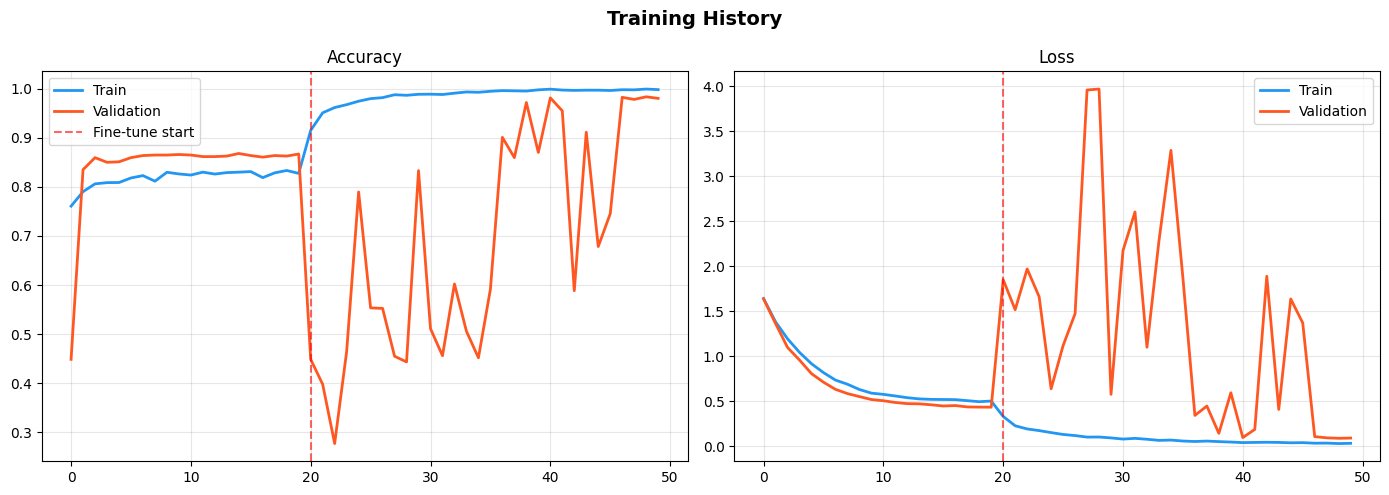


✅ Phase 2 complete!
   Best val accuracy : 98.31%
   Best val loss     : 0.0908


In [ ]:
print('🚀 Phase 2: fine-tuning full network ...')

base_model.trainable = True
risk_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_final.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

h2 = risk_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=cb2,
    verbose=1
)

risk_model.save('/content/risk_model_final.keras')

# ── Combined training curves ──
all_acc      = h1.history['accuracy']     + h2.history['accuracy']
all_val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
all_loss     = h1.history['loss']         + h2.history['loss']
all_val_loss = h1.history['val_loss']     + h2.history['val_loss']
ep1 = len(h1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')
ax1.plot(all_acc,     label='Train',      color='#2196F3', lw=2)
ax1.plot(all_val_acc, label='Validation', color='#FF5722', lw=2)
ax1.axvline(ep1, color='red', ls='--', alpha=0.6, label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(all_loss,     label='Train',      color='#2196F3', lw=2)
ax2.plot(all_val_loss, label='Validation', color='#FF5722', lw=2)
ax2.axvline(ep1, color='red', ls='--', alpha=0.6)
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

print(f'\n✅ Phase 2 complete!')
print(f'   Best val accuracy : {max(all_val_acc):.2%}')
print(f'   Best val loss     : {min(all_val_loss):.4f}')

## 📊 Cell 11 — Full Evaluation

Evaluating on test set...


Evaluating: 100%|██████████| 30/30 [00:19<00:00,  1.54it/s]



✅ Test Accuracy: 97.99%

📋 Per-class performance:
   🟢 nowildfire               : 98.82% ✅
   🔴 wildfire                 : 97.32% ✅

              precision    recall  f1-score   support

  nowildfire       0.97      0.99      0.98       422
    wildfire       0.99      0.97      0.98       523

    accuracy                           0.98       945
   macro avg       0.98      0.98      0.98       945
weighted avg       0.98      0.98      0.98       945



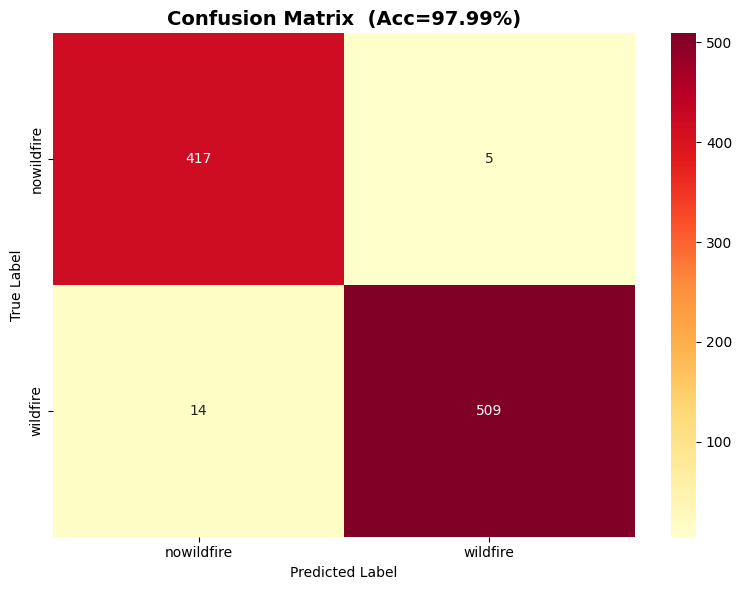

✅ Confusion matrix saved


In [ ]:
best_model = keras.models.load_model('/content/best_final.keras')

print('Evaluating on test set...')
y_true, y_pred, y_proba = [], [], []

for i in tqdm(range(len(test_gen)), desc='Evaluating'):
    imgs_b, lbls_b = test_gen[i]
    preds = best_model.predict(imgs_b, verbose=0)
    y_true.extend(lbls_b.tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_proba.extend(preds.tolist())

y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_proba = np.array(y_proba)

accuracy = np.mean(y_true == y_pred)
print(f'\n✅ Test Accuracy: {accuracy:.2%}')

print('\n📋 Per-class performance:')
for i, cls in enumerate(CLASS_NAMES):
    mask  = y_true == i
    if mask.sum() == 0: continue
    cacc  = (y_pred[mask] == i).mean()
    risk  = RISK_MAP[cls]
    icon  = '🔴' if risk=='High Risk' else '🟢'
    flag  = '✅' if cacc>=0.85 else '⚠️' if cacc>=0.70 else '❌'
    print(f'   {icon} {cls:25s}: {cacc:.2%} {flag}')

print('\n' + classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES*2), max(6, NUM_CLASSES*1.5)))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Confusion Matrix  (Acc={accuracy:.2%})', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved')

## 🔍 Cell 12 — Real Grad-CAM Implementation

✅ SmoothGrad works!  shape=(224, 224)  min=0.15  max=1.00  class=wildfire


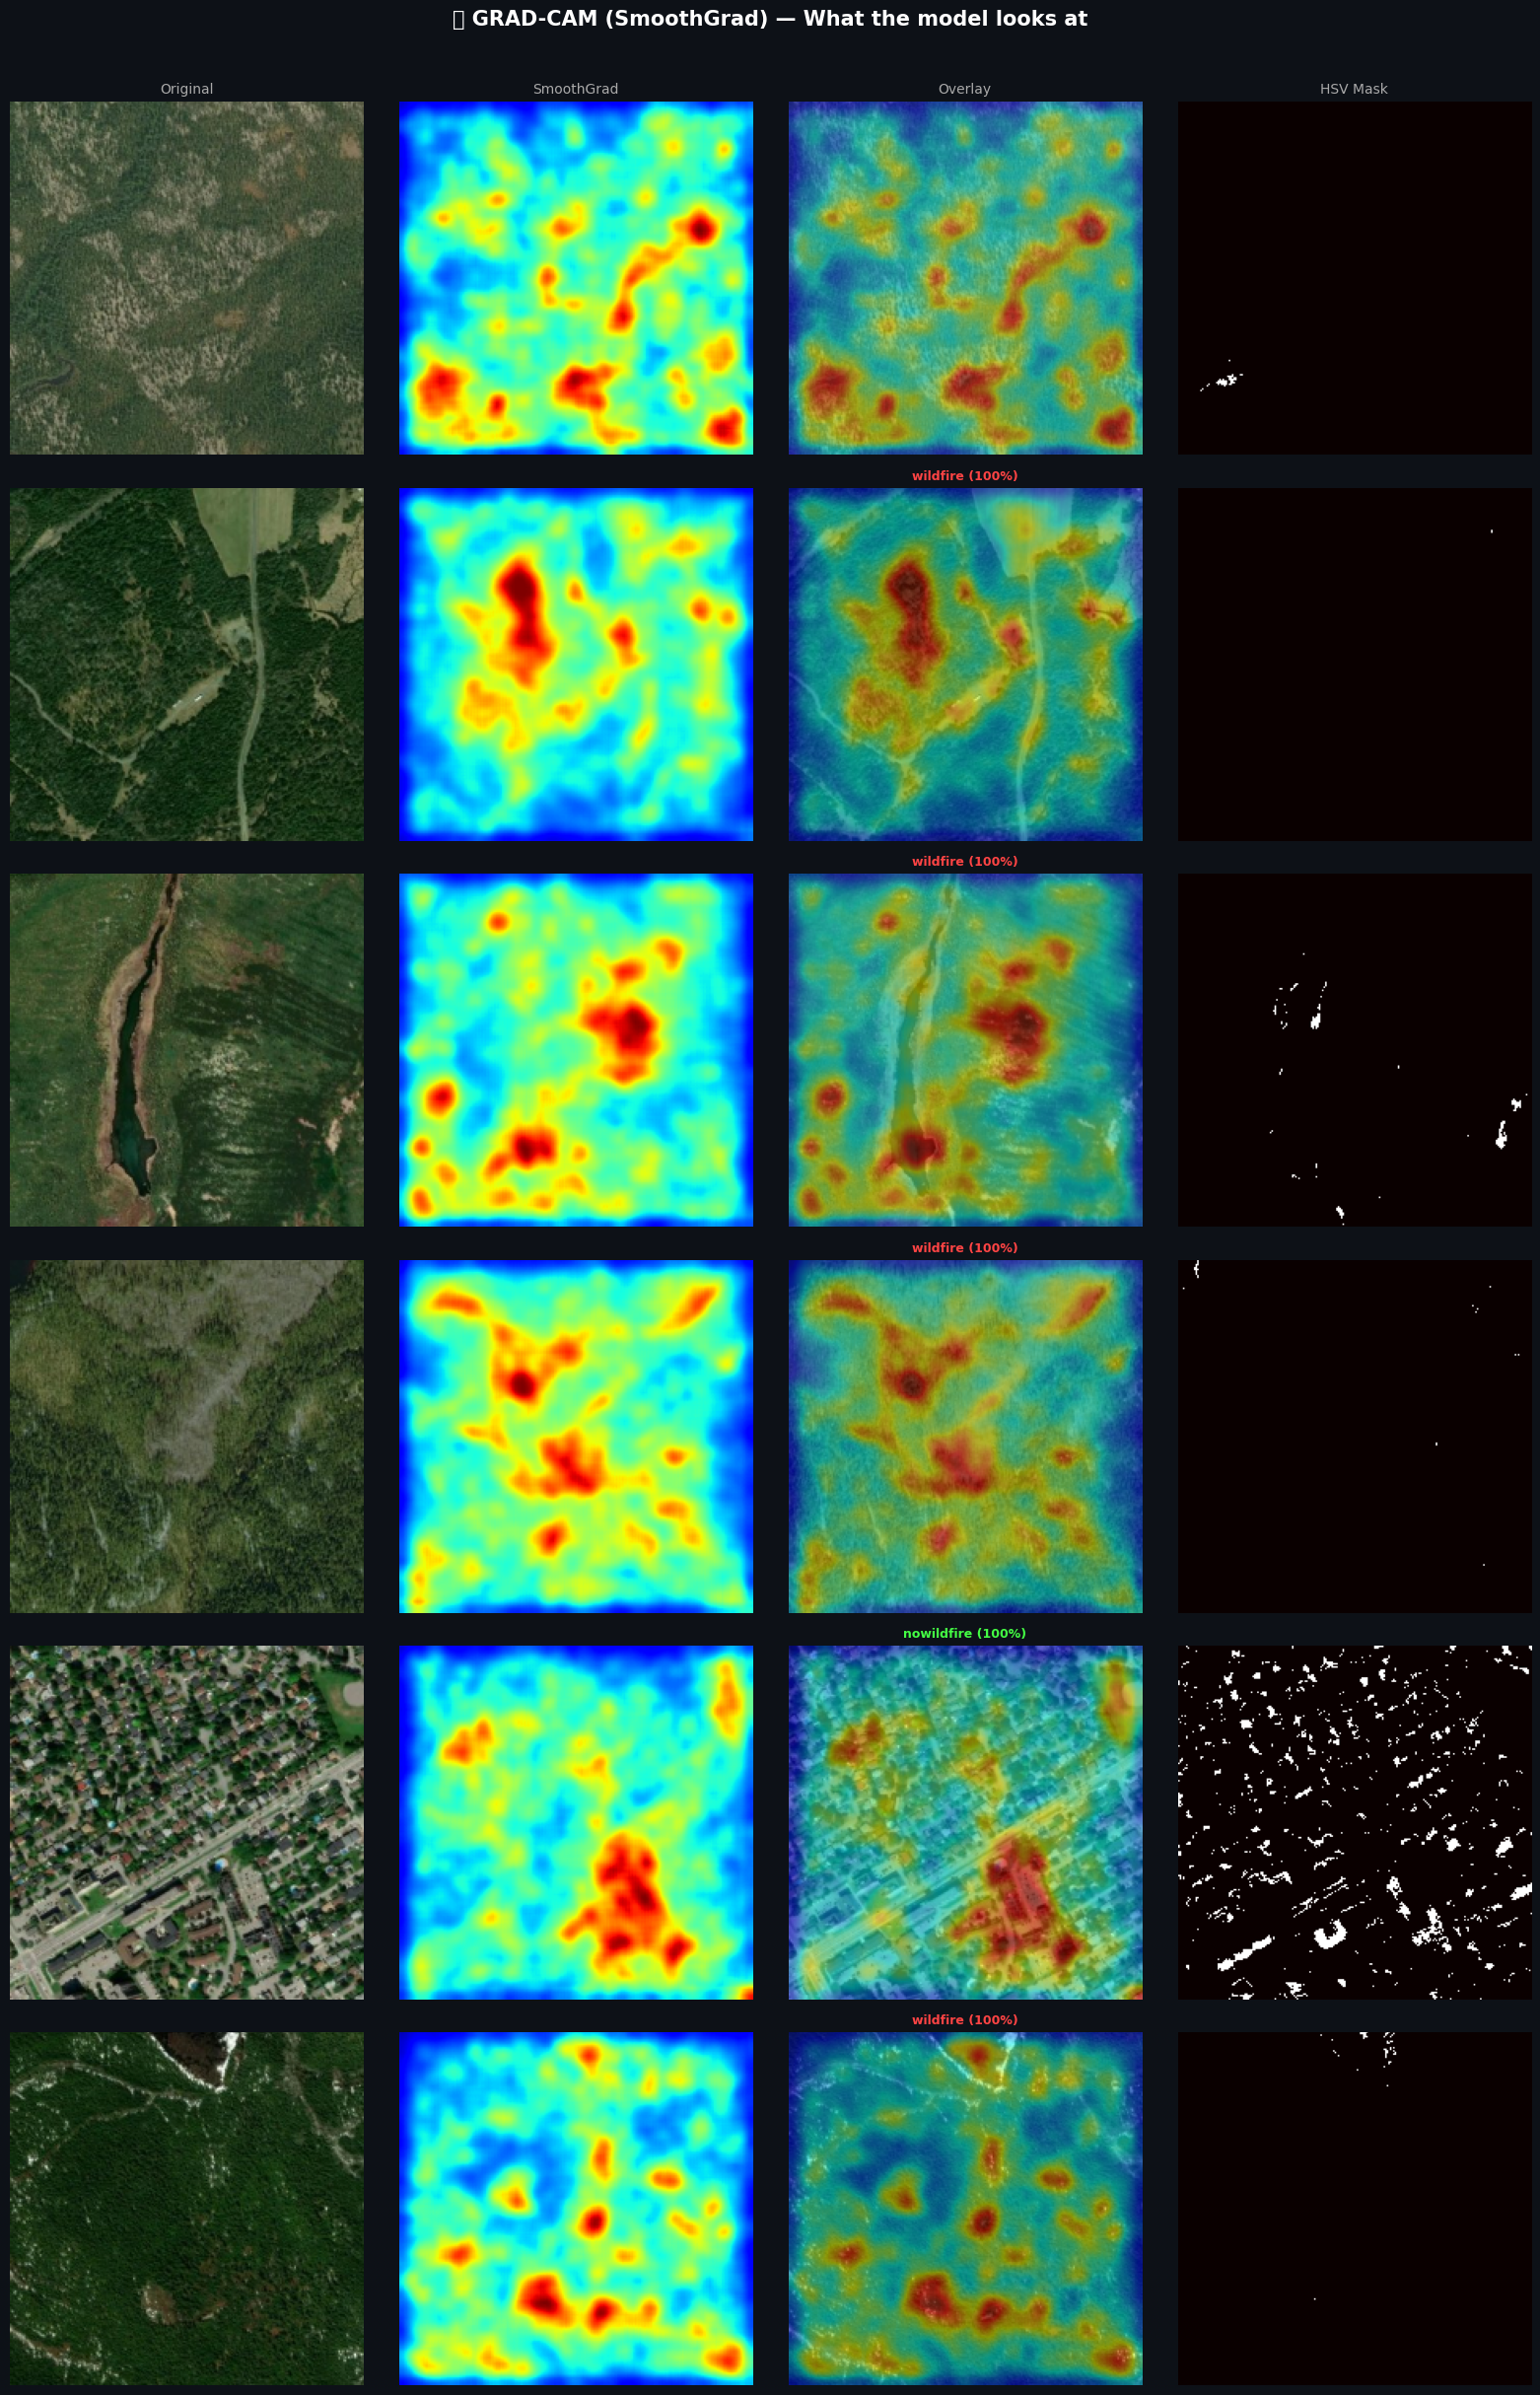

✅ Grad-CAM (SmoothGrad) complete!


In [ ]:
# ══════════════════════════════════════════════════════════════
# SMOOTHGRAD — Keras 3 proof, no layer name lookups needed.
# Averages input gradients over N slightly-noisy copies of the
# image → cleaner, more stable heatmap than standard Grad-CAM.
# ══════════════════════════════════════════════════════════════

def get_gradcam(model, img_minus1_1, class_idx=None, n_smooth=25):
    """
    img_minus1_1 : numpy (H, W, 3) float32 in [-1, 1]
    Returns       : heatmap (H, W) in [0, 1], predicted class idx
    """
    base   = img_minus1_1.astype(np.float32)
    noise  = 0.10   # std of noise relative to signal range

    grad_accum = np.zeros(base.shape[:2], dtype=np.float32)
    pred_class = class_idx

    for i in range(n_smooth):
        noisy = base + np.random.normal(0, noise, base.shape).astype(np.float32)
        inp_t = tf.Variable(noisy[np.newaxis], trainable=True)

        with tf.GradientTape() as tape:
            preds = model(inp_t, training=False)
            if pred_class is None:
                pred_class = int(tf.argmax(preds[0]))
            loss = preds[:, pred_class]

        grads = tape.gradient(loss, inp_t)          # (1, H, W, 3)
        # Max across colour channels → (H, W)
        grad_accum += np.max(np.abs(grads[0].numpy()), axis=-1)

    heatmap = grad_accum / n_smooth

    # Clip top 2% to remove outlier spikes, then normalise
    p98 = np.percentile(heatmap, 98)
    if p98 > 0:
        heatmap = np.clip(heatmap, 0, p98) / p98

    # Smooth for clean visuals
    heatmap = cv2.GaussianBlur(heatmap, (11, 11), 4)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    return heatmap, pred_class

def apply_colormap_overlay(orig_uint8, heatmap, alpha=0.50):
    jet  = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
    jet  = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    return np.clip(orig_uint8*(1-alpha) + jet*alpha, 0, 255).astype(np.uint8)

# ── quick sanity check before the full loop ──
_raw = cv2.imread(p_test[0])
_raw = cv2.cvtColor(_raw, cv2.COLOR_BGR2RGB)
_raw = cv2.resize(_raw, IMG_SIZE)
_inp = (_raw.astype(np.float32)/127.5) - 1.0
_h, _ci = get_gradcam(best_model, _inp)
print(f'✅ SmoothGrad works!  shape={_h.shape}  '
      f'min={_h.min():.2f}  max={_h.max():.2f}  '
      f'class={CLASS_NAMES[_ci]}')

# ── visualise 6 samples ──
sample_idxs = np.random.choice(len(p_test), 6, replace=False)
fig, axes   = plt.subplots(6, 4, figsize=(16, 24))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🔥 GRAD-CAM (SmoothGrad) — What the model looks at',
             color='white', fontsize=15, fontweight='bold', y=1.01)

for row, si in enumerate(sample_idxs):
    raw = cv2.imread(p_test[si])
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    raw = cv2.resize(raw, IMG_SIZE)
    inp = (raw.astype(np.float32)/127.5) - 1.0

    pred   = best_model.predict(inp[np.newaxis], verbose=0)[0]
    ci     = int(np.argmax(pred)); conf = pred[ci]
    name   = CLASS_NAMES[ci]; risk = RISK_MAP[name]
    true_n = CLASS_NAMES[l_test[si]]
    rc     = '#ff4444' if risk=='High Risk' else '#44ff44'
    correct = '✓' if ci==l_test[si] else '✗'

    hmap, _  = get_gradcam(best_model, inp, ci)
    overlay  = apply_colormap_overlay(raw, hmap)

    # HSV burnt mask
    hsv = cv2.cvtColor(raw, cv2.COLOR_RGB2HSV)
    m1  = cv2.inRange(hsv, np.array([0, 50,150]), np.array([15,255,255]))
    m2  = cv2.inRange(hsv, np.array([15,50,150]), np.array([30,255,255]))
    m3  = cv2.inRange(hsv, np.array([0,  0,  0]), np.array([180,50, 80]))
    hmask = cv2.bitwise_or(cv2.bitwise_or(m1,m2),m3).astype(np.float32)/255.

    axes[row,0].imshow(raw)
    axes[row,0].set_ylabel(f'True: {true_n}\n{correct}',
                           color='lime' if correct=='✓' else 'red',
                           fontsize=9, rotation=0, labelpad=65)
    axes[row,0].axis('off')
    axes[row,1].imshow(hmap, cmap='jet', vmin=0, vmax=1); axes[row,1].axis('off')
    axes[row,2].imshow(overlay)
    axes[row,2].set_title(f'{name} ({conf:.0%})', color=rc,
                          fontsize=9, fontweight='bold')
    axes[row,2].axis('off')
    axes[row,3].imshow(hmask, cmap='hot', vmin=0, vmax=1); axes[row,3].axis('off')
    for ax in axes[row]: ax.set_facecolor('#0d1117')

for ax, t in zip(axes[0], ['Original','SmoothGrad','Overlay','HSV Mask']):
    ax.set_title(t, color='#aaaaaa', fontsize=10)

plt.tight_layout()
plt.savefig('/content/gradcam_results.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Grad-CAM (SmoothGrad) complete!')